# Pandas Hands-On Project: Superstore Dataset

## Objective
The objective of this project is to explore, clean, and perform feature engineering on the Superstore dataset using Pandas.

This analysis will help understand the dataset structure, handle missing values, and create meaningful new features.

##  Task 1: Load & Explore Data

In this section, we load the dataset and perform initial exploration to understand its structure and contents.

In [1]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Sample - Superstore.csv', encoding='latin1')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
# Summary statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### 📌 Insight
The dataset contains sales records including customer details, product information, and transaction values.

- The dataset includes both numerical and categorical columns.
- Some columns like Order Date and Ship Date are not yet in datetime format.

- Sales and Profit show a wide range of values.
- Discount varies across transactions.
- Some transactions may have low or negative profit.

## 🔹 Task 2: Data Cleaning

This step involves identifying and handling missing values, and correcting data types.

In [8]:
# Check missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
# Handle missing values
df['Postal Code'] = df['Postal Code'].fillna(0)

### Explanation
Missing values in the Postal Code column are filled with 0 to avoid losing data.

In [10]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

### Insight
Converting date columns allows time-based analysis such as monthly or yearly trends.

## Task 3: Feature Engineering

In this section, new features are created to enhance analysis.

In [11]:
# Extract Month and Year
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

df[['Order Date', 'Order Month', 'Order Year']].head()

,Order Date,Order Month,Order Year
0,2016-11-08,11,2016
1,2016-11-08,11,2016
2,2016-06-12,6,2016
3,2015-10-11,10,2015
4,2015-10-11,10,2015


In [12]:
# Create new feature: Profit Ratio
df['Profit Ratio'] = df['Profit'] / df['Sales']

df[['Sales', 'Profit', 'Profit Ratio']].head()

,Sales,Profit,Profit Ratio
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


### Explanation
Profit Ratio indicates how much profit is generated per unit of sales.
Higher values indicate better performance.

In [13]:
# Verify new feature
df['Profit Ratio'].describe()

,Profit Ratio
count,9994.000000
mean,0.120314
std,0.466754
min,-2.750000
25%,0.075000
50%,0.270000
75%,0.362500
max,0.500000


### Insight
- The distribution of Profit Ratio helps identify profitable vs unprofitable transactions.
- Extreme values should be checked for anomalies.

##  Task 4: GroupBy & Aggregation

This section uses groupby operations to summarize the dataset and extract meaningful insights.

In [14]:
# Total Sales by Category
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sales_by_category

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [15]:
# Total Profit by Region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
profit_by_region

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


In [16]:
# Top 5 Customers by Sales
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571


In [17]:
# Monthly Sales Trend
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum()
monthly_sales

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
            2               22978.8150
            3               51715.8750
            4               38750.0390
            5               56987.7280
            6               40344.5340
            7               39261.9630
            8               31115.3743
            9               73410.0249
            10              59687.7450
            11              79411.9658
            12              96999.0430
2017        1               43971.3740
            2               20301.1334
            3               58872.3528
            4               36521.5361
            5               44261.1102
            6               52981.7257
            7               45264.4160
            8               63120.8880
            9               87866.6520
            10              77776.9232
            11             118447.8250
            12              83829.3188
Name: Sales, dtype: float64

### Insight
Grouping by year and month helps identify seasonal sales patterns and trends over time.

## Task 5: Pivot Tables

Pivot tables provide a more structured way to summarize data across multiple dimensions.

In [18]:
# Sales by Category and Region
pivot_sales = pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')
pivot_sales

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


In [19]:
# Sales Trends by Segment over Time
pivot_segment = pd.pivot_table(df, values='Sales', index='Order Month', columns='Segment', aggfunc='sum')
pivot_segment

Segment,Consumer,Corporate,Home Office
Order Month,,,
1,50441.2906,26790.3480,17693.1970
2,33826.1760,14575.0670,11350.0084
3,89174.7070,58239.9132,57590.8686
4,54845.1895,49233.1636,33683.7755
5,86932.7144,47289.0323,20807.0650
6,82910.1803,40858.5370,28949.9620
7,81769.7730,46919.2060,18549.1180
8,82319.8063,57529.4477,19194.8090
9,185055.9196,74020.2213,48573.8048


In [20]:
# Profit by Sub-Category
pivot_profit = pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum').sort_values(by='Profit', ascending=False)
pivot_profit

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


### Insight
Pivot tables simplify multi-dimensional analysis and make comparisons easier.

##  Task 6: Data Splitting & Merging

The dataset is split into meaningful subsets and then merged back together.

In [21]:
# Split dataset
df_customers = df[['Customer ID', 'Customer Name', 'Segment']]
df_orders = df[['Customer ID', 'Order Date', 'Sales', 'Profit']]

In [22]:
# Merge datasets
merged_df = pd.merge(df_orders, df_customers, on='Customer ID', how='inner')
merged_df.head()

,Customer ID,Order Date,Sales,Profit,Customer Name,Segment
0,CG-12520,2016-11-08,261.96,41.9136,Claire Gute,Consumer
1,CG-12520,2016-11-08,261.96,41.9136,Claire Gute,Consumer
2,CG-12520,2016-11-08,261.96,41.9136,Claire Gute,Consumer
3,CG-12520,2016-11-08,261.96,41.9136,Claire Gute,Consumer
4,CG-12520,2016-11-08,261.96,41.9136,Claire Gute,Consumer


### Verification
The merge is successful if:
- Rows are not unexpectedly reduced
- Columns from both datasets appear correctly

## Task 7: Data Visualization

Visualizations help in understanding patterns and trends in the dataset.

In [24]:
import matplotlib.pyplot as plt

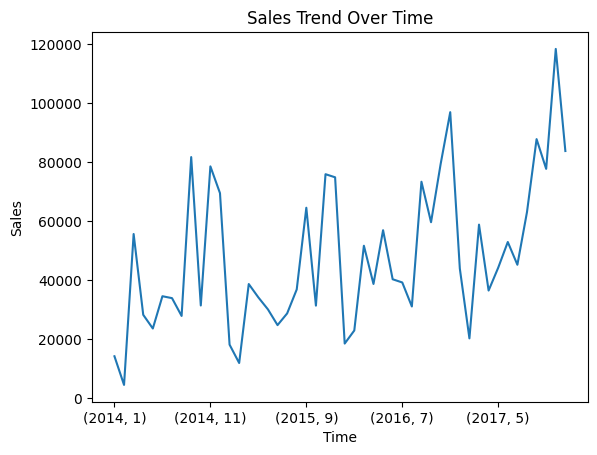

In [25]:
# Line Chart: Sales Trend
monthly_sales.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

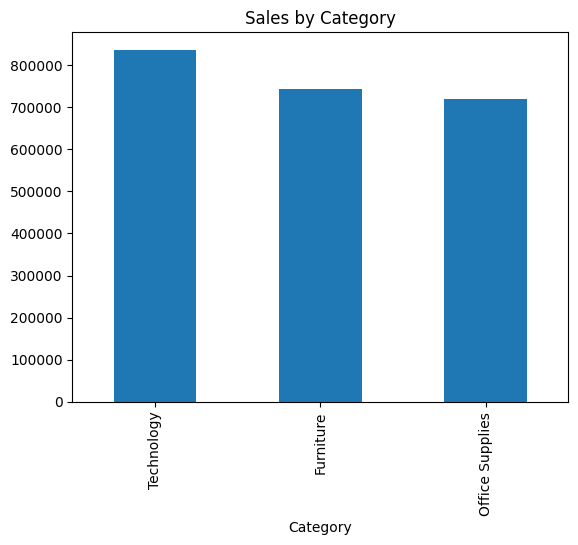

In [26]:
# Bar Chart: Sales by Category
sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

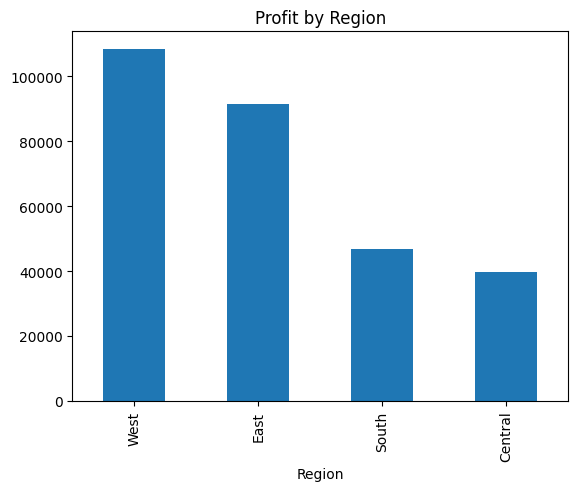

In [27]:
# Bar Chart: Profit by Region
profit_by_region.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

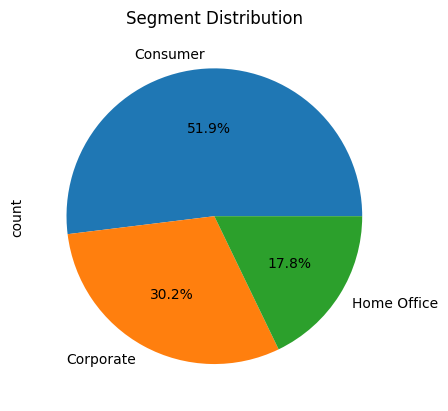

In [28]:
# Pie Chart: Segment Distribution
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.show()

###  Insight
Visualizations reveal patterns that are not immediately obvious from raw data.

## Task 8: Key Insights

Based on the analysis performed above, the following conclusions can be drawn:

### Findings

- **Most Profitable Category:**  
  The category with the highest total profit is identified from the aggregation results.

- **Least Performing Region:**  
  The region with the lowest profit indicates weaker performance.

- **Sales vs Profit Pattern:**  
  Higher sales do not always guarantee higher profit due to discounts and costs.

- **Trends Over Time:**  
  Sales show fluctuations across months, indicating possible seasonality.